# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pathlib as Path
import sys
import pandas as pd
from tqdm import tqdm


import torchvision.utils as vutils


### Import SRC files 

In [2]:
from src.config import *
import src.datafunctions as DF
import src.vq_vae as VQ 


In [3]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [5]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = DF.get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.Size([128, 1, 28, 28]) torch.Size([128])


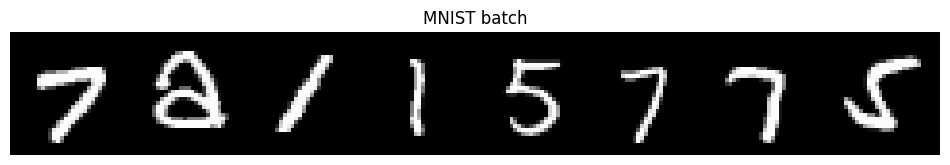

torch.Size([128, 1, 28, 28]) torch.Size([128])


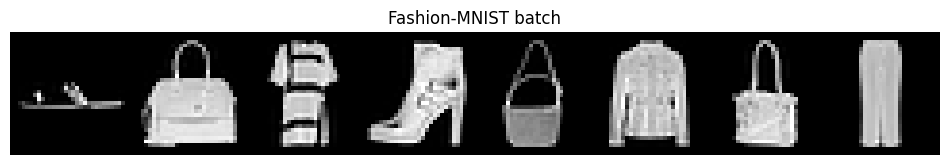

torch.Size([128, 3, 32, 32]) torch.Size([128])


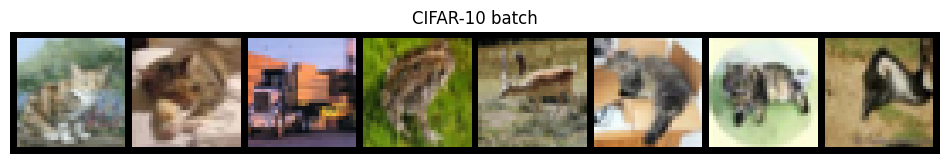

In [6]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

## VQ-VAE dev section

Add complexity, by introducing up- down- and res- blocks that can be tuned 

In [7]:
# The number of code book embeddings
code_book_size = 32

hidden_channels = 10

vq_nepoch = dev_EPOCHS


In [11]:
vae_net = VQ.VQVAE(in_channels=mnist_in_channels, hidden_channels=hidden_channels,
                   latent_dim=LATENT_DIM, code_book_size=code_book_size, commitment_cost=0.25).to(device)

optimizer = torch.optim.Adam(vae_net.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=0)

history = VQ.train_vqvae(
    model=vae_net,
    train_loader=mnist_train,
    test_loader=mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=False,
)

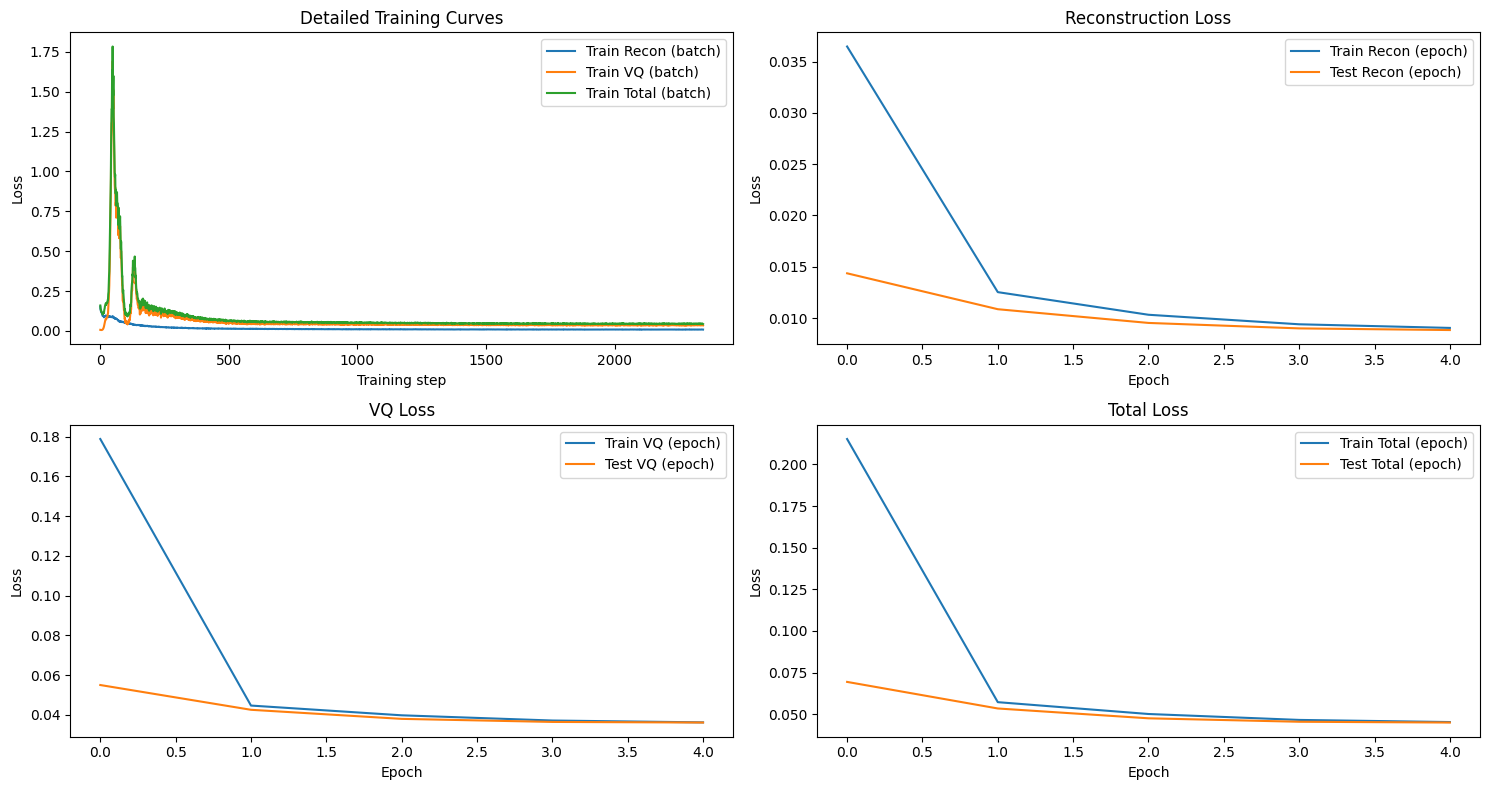

Final Metrics
Train Recon Loss: 0.009041
Train VQ Loss:    0.036252
Train Total Loss: 0.045293
Test Recon Loss:  0.008833
Test VQ Loss:     0.036166
Test Total Loss:  0.044999

Final batch reconstruction MSE: 0.006678
Batch VQ loss: 0.028376
Quantized latent shape: torch.Size([8, 64, 7, 7])
Encoding indices shape: torch.Size([8, 7, 7])


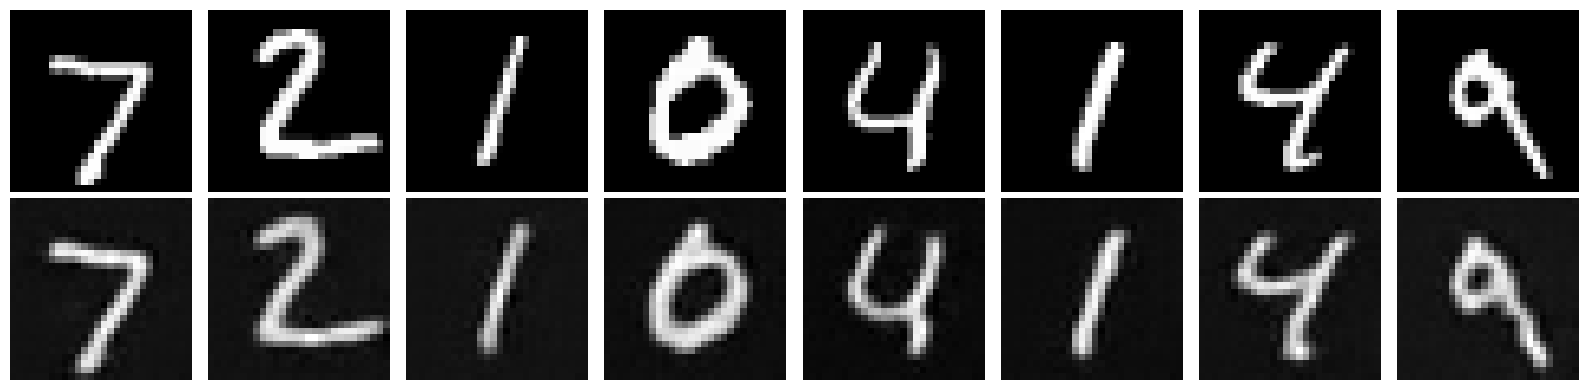

In [12]:
VQ.show_vqvae_results(history, mnist_test, device, num_images=8)


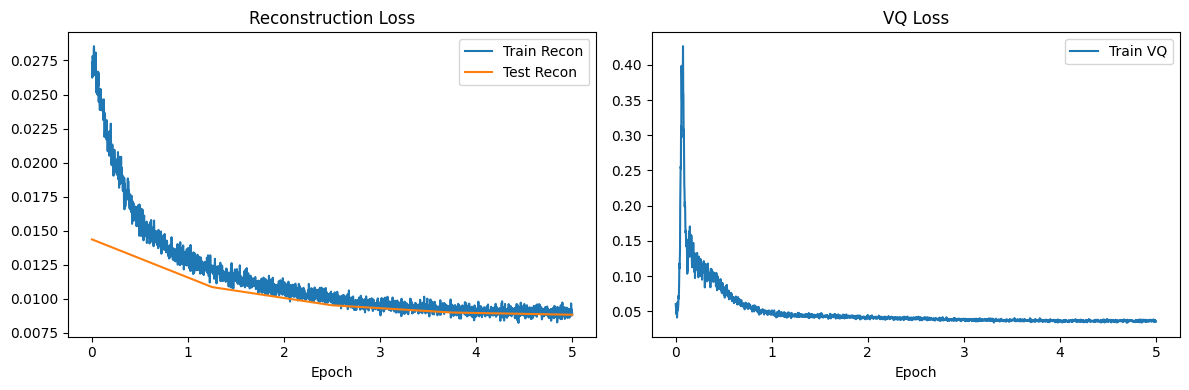

In [13]:
VQ.show_vqvae_curves(history, vq_nepoch)